# 📋 Filtrado de lista de términos jurídicos

Este cuaderno analiza y filtra la lista `listadeterminosjur.txt`,
que contiene **1260 términos jurídicos** extraídos automáticamente de documentos legales,
junto con su frecuencia de aparición.

## Problema

La extracción automática produce ruido inevitable:
términos demasiado genéricos, fragmentos de frases, duplicados, artefactos de formato
y entradas de baja frecuencia que probablemente son errores de extracción.

## Filtros aplicados

| ID | Filtro | Criterio |
|---|---|---|
| F0 | **Artefactos de formato** | Comillas, números al inicio, referencias cruzadas |
| F1 | **Términos genéricos** | Palabras comunes sin valor jurídico específico |
| F2 | **Términos truncados** | Preposición o artículo al final del término |
| F3 | **Duplicados morfológicos** | Singular/plural o un término contenido en otro |
| F4 | **Baja frecuencia contextual** | Frecuencia = 1 y sin valor jurídico claro |

Cada término eliminado se registra con el motivo exacto.
Al final se obtiene la lista limpia con clasificación por dominio (Tributario / Laboral).


## 0. Instalación

In [1]:
!pip install -q matplotlib seaborn pandas tabulate openpyxl
print("✅ OK")


✅ OK


## 1. Carga del fichero

In [4]:
import re, os
from collections import Counter, defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

pd.set_option("display.max_colwidth", 70)
pd.set_option("display.max_rows", 50)

# ── Lectura ────────────────────────────────────────────────────
FILE = "listadeterminosjur.txt"

# Si ejecutas en Colab, sube el fichero primero:
from google.colab import files; files.upload()

terms_raw = []
with open(FILE, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        if ": " in line:
            parts = line.rsplit(": ", 1)
            if len(parts) == 2:
                term, count = parts[0].strip(), parts[1].strip()
                try:
                    terms_raw.append({"término": term, "frecuencia": int(count)})
                except ValueError:
                    pass

df_orig = pd.DataFrame(terms_raw)
print(f"✅ Fichero cargado: {len(df_orig)} términos")
print(f"   Frecuencia máxima : {df_orig.frecuencia.max()} "
      f"('{df_orig.loc[df_orig.frecuencia.idxmax(), 'término']}')")
print(f"   Frecuencia mínima : {df_orig.frecuencia.min()}")
print(f"   Frecuencia media  : {df_orig.frecuencia.mean():.1f}")
print(f"   Total apariciones : {df_orig.frecuencia.sum()}")
print()
print("Primeros 10 términos:")
print(df_orig.head(10).to_string(index=False))


Saving filtrado_terminos_juridicos.ipynb to filtrado_terminos_juridicos.ipynb


FileNotFoundError: [Errno 2] No such file or directory: 'listadeterminosjur.txt'

In [5]:


# 📦 Imports
import re, os
from collections import Counter, defaultdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

pd.set_option("display.max_colwidth", 70)
pd.set_option("display.max_rows", 50)

# 📂 Subir archivo en Colab
from google.colab import files
uploaded = files.upload()

# 📄 Obtener nombre del archivo automáticamente
FILE = list(uploaded.keys())[0]

# ── Lectura ────────────────────────────────────────────────────
terms_raw = []

with open(FILE, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        if ": " in line:
            parts = line.rsplit(": ", 1)
            if len(parts) == 2:
                term, count = parts[0].strip(), parts[1].strip()
                try:
                    terms_raw.append({
                        "término": term,
                        "frecuencia": int(count)
                    })
                except ValueError:
                    pass

df_orig = pd.DataFrame(terms_raw)

# 📊 Estadísticas
print(f"✅ Fichero cargado: {len(df_orig)} términos")

if not df_orig.empty:
    print(f"   Frecuencia máxima : {df_orig.frecuencia.max()} "
          f"('{df_orig.loc[df_orig.frecuencia.idxmax(), 'término']}')")
    print(f"   Frecuencia mínima : {df_orig.frecuencia.min()}")
    print(f"   Frecuencia media  : {df_orig.frecuencia.mean():.1f}")
    print(f"   Total apariciones : {df_orig.frecuencia.sum()}")

print()
print("Primeros 10 términos:")
print(df_orig.head(10).to_string(index=False))

Saving listadeterminosjur.txt to listadeterminosjur.txt
✅ Fichero cargado: 1260 términos
   Frecuencia máxima : 84 ('pago')
   Frecuencia mínima : 1
   Frecuencia media  : 3.0
   Total apariciones : 3745

Primeros 10 términos:
                             término  frecuencia
                                pago          84
                     fraccionamiento          54
                               plazo          54
                             trabajo          43
                                aeat          38
reclamación económico administrativa          38
                            artículo          38
                             acuerdo          36
                        aplazamiento          35
                            contrato          35


## 2. Análisis exploratorio

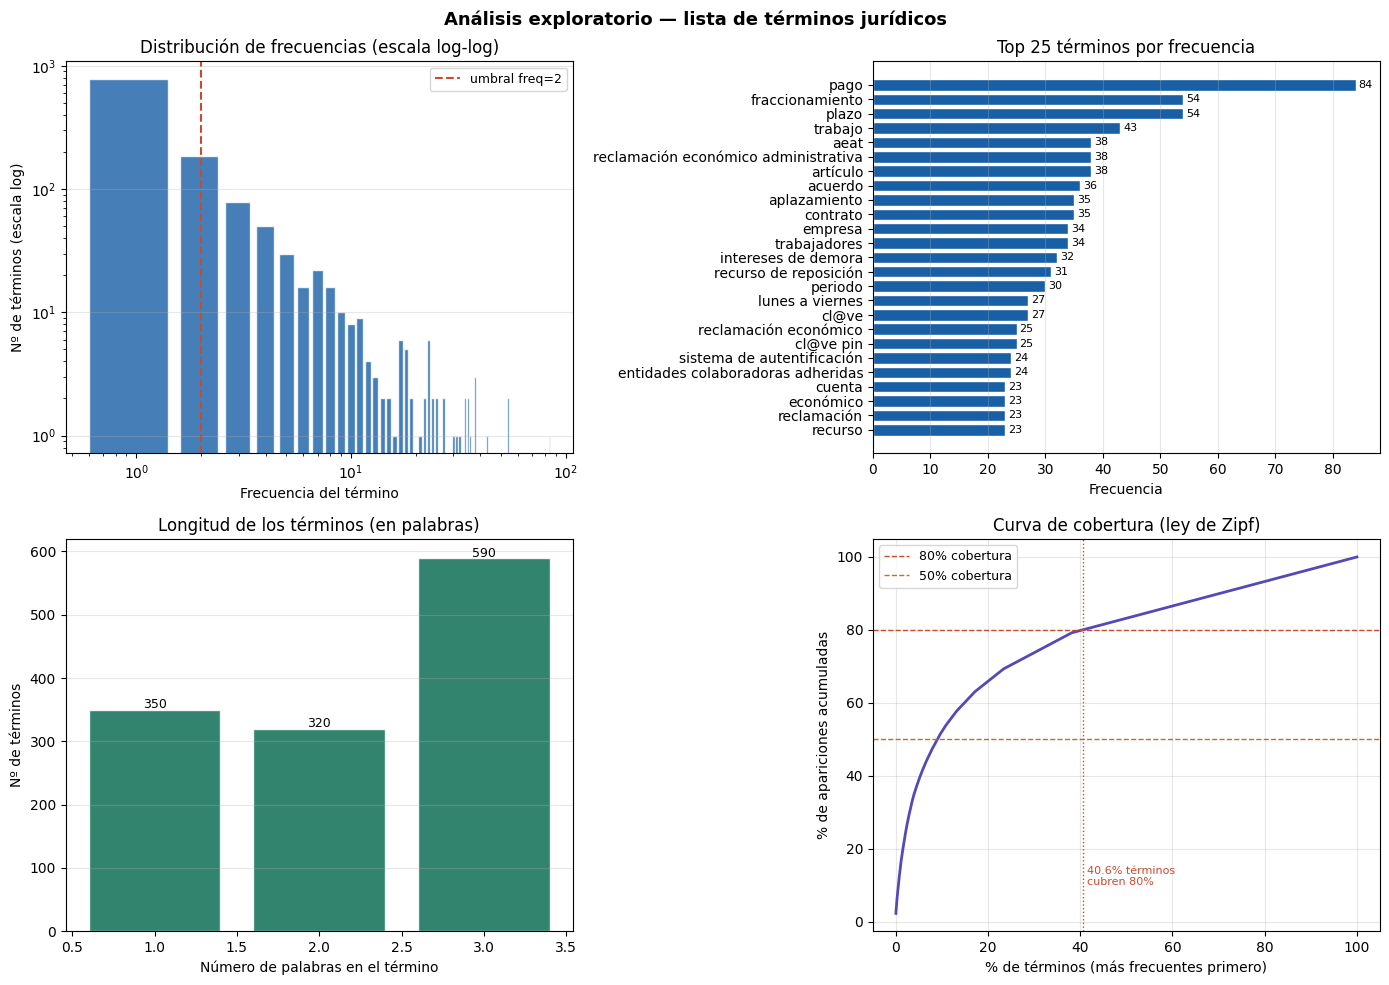


📊 Términos con frecuencia = 1: 780 (61.9%)
   Términos con frecuencia ≤ 2: 966 (76.7%)
   El 40.6% de los términos cubre el 80% de todas las apariciones


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Análisis exploratorio — lista de términos jurídicos", fontsize=13, fontweight="bold")

# ── 2a. Distribución de frecuencias (log) ────────────────────
ax = axes[0, 0]
freq_counts = df_orig["frecuencia"].value_counts().sort_index()
ax.bar(freq_counts.index, freq_counts.values, color="#185FA5", alpha=0.8, edgecolor="white")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_xlabel("Frecuencia del término")
ax.set_ylabel("Nº de términos (escala log)")
ax.set_title("Distribución de frecuencias (escala log-log)")
ax.grid(axis="y", alpha=0.3)
ax.axvline(2, color="#C84B2F", ls="--", lw=1.5, label="umbral freq=2")
ax.legend(fontsize=9)

# ── 2b. Top 25 términos más frecuentes ───────────────────────
ax = axes[0, 1]
top25 = df_orig.nlargest(25, "frecuencia")
colors_top = ["#185FA5"] * 25
ax.barh(top25["término"][::-1], top25["frecuencia"][::-1],
        color=colors_top, edgecolor="white")
ax.set_xlabel("Frecuencia")
ax.set_title("Top 25 términos por frecuencia")
ax.grid(axis="x", alpha=0.3)
for i, (_, row) in enumerate(top25[::-1].iterrows()):
    ax.text(row["frecuencia"] + 0.5, i, str(row["frecuencia"]), va="center", fontsize=8)

# ── 2c. Longitud de los términos ─────────────────────────────
ax = axes[1, 0]
df_orig["n_palabras"] = df_orig["término"].apply(lambda x: len(x.split()))
df_orig["n_chars"]    = df_orig["término"].apply(len)
npal_counts = df_orig["n_palabras"].value_counts().sort_index()
ax.bar(npal_counts.index, npal_counts.values, color="#0F6E56", alpha=0.85, edgecolor="white")
ax.set_xlabel("Número de palabras en el término")
ax.set_ylabel("Nº de términos")
ax.set_title("Longitud de los términos (en palabras)")
ax.grid(axis="y", alpha=0.3)
for x, y in zip(npal_counts.index, npal_counts.values):
    ax.text(x, y + 2, str(y), ha="center", fontsize=9)

# ── 2d. Acumulado de cobertura por frecuencia ────────────────
ax = axes[1, 1]
df_sorted = df_orig.sort_values("frecuencia", ascending=False)
cumulative_terms = np.arange(1, len(df_sorted) + 1) / len(df_sorted) * 100
cumulative_freq  = df_sorted["frecuencia"].cumsum() / df_sorted["frecuencia"].sum() * 100
ax.plot(cumulative_terms, cumulative_freq, color="#534AB7", lw=2)
ax.axhline(80, color="#C84B2F", ls="--", lw=1, label="80% cobertura")
ax.axhline(50, color="#BA7517", ls="--", lw=1, label="50% cobertura")
idx_80 = np.searchsorted(cumulative_freq.values, 80)
ax.axvline(cumulative_terms[idx_80], color="#C84B2F", ls=":", lw=1)
ax.text(
    cumulative_terms[idx_80] + 1,
    10,
    f"{cumulative_terms[idx_80]:.1f}% términos\ncubren 80%",
    fontsize=8,
    color="#C84B2F"
)
ax.set_xlabel("% de términos (más frecuentes primero)")
ax.set_ylabel("% de apariciones acumuladas")
ax.set_title("Curva de cobertura (ley de Zipf)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("analisis_exploratorio.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n📊 Términos con frecuencia = 1: {(df_orig.frecuencia==1).sum()} "
      f"({(df_orig.frecuencia==1).mean()*100:.1f}%)")
print(f"   Términos con frecuencia ≤ 2: {(df_orig.frecuencia<=2).sum()} "
      f"({(df_orig.frecuencia<=2).mean()*100:.1f}%)")
print(f"   El {cumulative_terms[idx_80]:.1f}% de los términos cubre el 80% de todas las apariciones")


## 3. Definición y aplicación de filtros

In [8]:
# ════════════════════════════════════════════════════════════════
# FILTRO 0 — Artefactos de formato
# Elimina entradas que son claramente errores del extractor:
#   - Empiezan o terminan con comilla tipográfica
#   - Son referencias cruzadas ("véase X")
#   - Empiezan con número (referencias a leyes sueltas)
#   - Términos con paréntesis mal cerrados o fragmentos de código
# ════════════════════════════════════════════════════════════════

ARTEFACTO_PATTERNS = [
    (r'^["\"«»""]',        "Empieza con comilla"),
    (r'["\"«»""]$',        "Termina con comilla"),
    (r'^véase[s]?',       "Referencia cruzada (véase)"),
    (r'^véanse[s]?',      "Referencia cruzada (véanse)"),
    (r'^\d{2}/',           "Referencia normativa suelta (ej. 36/2011)"),
    (r'^«',                 "Marcador de cita «"),
    (r'application móvil"', "Fragmento partido"),
    (r'^"',                 "Comilla inicial"),
    (r'^\d+/\d+$',        "Solo número de norma"),
]

def is_artefacto(term):
    for pattern, motivo in ARTEFACTO_PATTERNS:
        if re.search(pattern, term, re.IGNORECASE):
            return motivo
    return None

# ════════════════════════════════════════════════════════════════
# FILTRO 1 — Términos genéricos sin valor jurídico específico
# Palabras o expresiones comunes que aparecen en cualquier texto
# y no aportan terminología jurídica diferencial.
# ════════════════════════════════════════════════════════════════

GENERICOS = {
    # pronombres, adverbios, conjunciones con sustantivación
    "través","tanto","respecto","vez","manera","modo","forma","tipo",
    "caso","momento","lugar","base","punto","uso","nivel","clase",
    # sustantivos demasiado generales
    "persona","personas","días","meses","semana","semanas","horas","hora",
    "tiempo","fecha","número","información","texto","objeto","efectos",
    "causa","causas","medida","medidas","contenido","marco","cargo","orden",
    "grupo","común","lista","correo","mesa","agencia","atención","parte",
    "formas","actos","obras","normas","disposición","disposiciones",
    "derechos","organizaciones","participación","perjuicio","conformidad",
    "motivos","órganos","tanto","ventura","encabezamiento","elegibles",
    "resultase","hacérsele","discordancia","setecientos","sexiesdecies",
    # referencias bibliográficas / editoriales
    "véase","véanse","encabezamiento","presencialmente","artículo","artículos",
    "real",  # solo como sustantivo, no "Real Decreto" etc.
    "general", "social", "seguridad","electrónica",
    # palabras que solo cobran sentido en contexto
    "inicio","cambio","cambios","situación","evolución","resultado",
    "partes","servicios","acuerdos","convenios","contratos","centros",
    "delegados","trabajadores","trabajadoras","empresas","organizaciones",
    "representantes","solicitudes","condiciones","disposiciones","medidas",
    "normas","derechos","actuaciones","fracciones","consultas","elecciones",
    "entidad","entidades","dirección","puesto","puestos","personal","pacto",
    "fines","adopción" if False else None,  # adopción sí es jurídico
    "igualdad","seguro","código","título","texto","causa","proceso",
    "realización","elegibles","ventura","tanto","respecto","contenido",
    "marco","cargo","orden","común","grupo","medida","atención","órganos",
    "formas","perjuicio","conformidad","participación","setecientos",
    "artículos","trabajos","acuerdos",
}
GENERICOS.discard(None)

def is_generico(term):
    tl = term.lower().strip()
    if tl in GENERICOS:
        return f"Término genérico sin valor jurídico específico: '{term}'"
    return None

# ════════════════════════════════════════════════════════════════
# FILTRO 2 — Términos truncados
# Términos que terminan en preposición, artículo o conjunción
# y que claramente son el inicio de una frase más larga.
# ════════════════════════════════════════════════════════════════

TRAILING_PREP = re.compile(
    r"\b(de|del|de la|de los|de las|en|a|por|con|el|la|los|las|"
    r"para|al|que|sobre|ante|bajo|entre|sin|tras)$",
    re.IGNORECASE
)

def is_truncado(term):
    if TRAILING_PREP.search(term.strip()):
        last_word = term.strip().split()[-1]
        return f"Término truncado: termina en '{last_word}' (preposición/artículo)"
    return None

# ════════════════════════════════════════════════════════════════
# FILTRO 3 — Duplicados morfológicos
# Un término es duplicado cuando:
#   a) Es el plural de otro término ya presente
#   b) Está completamente contenido en otro término más específico
#      con una frecuencia similar o mayor
# Estrategia: conservar el más específico (más palabras) o el de
# mayor frecuencia cuando hay empate.
# ════════════════════════════════════════════════════════════════

def find_duplicates(term_freq_list):
    """
    Devuelve un dict: término_a_eliminar -> (motivo, término_preferido)
    """
    terms_dict = {t: f for t, f in term_freq_list}
    to_remove = {}

    for t1, f1 in term_freq_list:
        if t1 in to_remove:
            continue
        t1l = t1.lower()
        for t2, f2 in term_freq_list:
            if t1 == t2 or t2 in to_remove:
                continue
            t2l = t2.lower()

            # Caso a: plural simple (t1 + s = t2 o t1 + es = t2)
            if t1l + "s" == t2l or t1l + "es" == t2l:
                # Conservar el singular si tiene más o igual frecuencia
                if f1 >= f2:
                    to_remove[t2] = (
                        f"Plural de '{t1}' (frecuencia {f2} ≤ {f1})",
                        t1
                    )
                else:
                    to_remove[t1] = (
                        f"Singular de '{t2}' con menor frecuencia ({f1} < {f2})",
                        t2
                    )

            # Caso b: t1 está contenido en t2 y es mucho más corto
            elif (t1l in t2l and
                  len(t1.split()) < len(t2.split()) and
                  len(t2.split()) - len(t1.split()) <= 2):
                # El más corto es ambiguo → marcar para revisión, no eliminar automáticamente
                # Solo eliminar si el más corto tiene 1 palabra y el más largo ≥ 2
                if len(t1.split()) == 1 and len(t2.split()) >= 2 and f2 >= f1 * 0.5:
                    if t1 not in to_remove:
                        to_remove[t1] = (
                            f"Término genérico subsumido en '{t2}' (más específico)",
                            t2
                        )

    return to_remove

# ════════════════════════════════════════════════════════════════
# FILTRO 4 — Baja frecuencia + sin valor jurídico claro
# Términos con frecuencia = 1 que además:
#   - Son de 1 sola palabra sin especificidad jurídica
#   - Contienen palabras que indican error de extracción
# Los términos compuestos (≥2 palabras) con frecuencia=1
# se conservan si parecen terminología específica.
# ════════════════════════════════════════════════════════════════

# Palabras que en términos de 1 sola palabra con freq=1 indican no-terminología
NON_LEGAL_SINGLE = {
    "encabezamiento","presencialmente","correo","mesa","agencia","zona",
    "motivo","razón","religión","consecuencias","cambio","antelación","usos",
    "consejo","distancia","capítulo","términos","plan","enero","marzo",
    "julio","diciembre","mónaco","supuesto","hijo","madre","riesgo",
    "habilitante","ción","septies","vigesimoctava","tanto","ventura",
    "jefe","copia","lista","colegio","aprendizaje","letra","partes",
    "documento","acto","elección","manera","deberes","deliberaciones",
    "mujeres","cambios","servicios","años","miembros","sindicatos",
    "administraciones","adicional","párrafo","prueba","instancia","faltas",
    "oscilaciones","infracciones","fuerza","carácter","prefencia",
    "vigilancia","efecto","relaciones","modificaciones","motivadora",
    "atención","órganos","formas","perjuicio","conformidad","participación",
    "setecientos","hacérsele","resultase","elegibles","discordancia",
    "inicio","situación","evolución","resultado","guarda","extranjeros",
    "facturas","deber","inviolabilidad","protección","titulación","práctica",
    "sexo","salarial","valor","oscilaciones","consanguinidad","acogimiento",
    "laudos","prescripción","concursal","microacreditaciones","unidad",
    "organización","corresponsabilidad","mecanismo","recualificación",
    "convocatoria","vigencia","partes","extinciones","mancomunadamente",
    "clave","autentificación","autentificación","letra","administración",
    "criterios","vacaciones","incapacidad","párrafo","instancia","evolución",
    "situación","consecuencias","antelación","usos","consejo","ministros",
    "desempleo","extraordinarias","colaboradora","zona",
}

def is_baja_frecuencia_no_juridico(term, freq):
    if freq > 1:
        return None
    # Término de 1 sola palabra con freq=1 y no es terminología jurídica
    if len(term.split()) == 1 and term.lower() in NON_LEGAL_SINGLE:
        return f"1 sola palabra, frecuencia=1, sin especificidad jurídica"
    # Términos que son solo números de artículo/norma
    if re.match(r"^\d+/\d+$", term) or re.match(r"^\d+$", term):
        return f"Referencia numérica sin contexto (frecuencia=1)"
    return None

print("✅ Filtros definidos: F0 (artefactos), F1 (genéricos), F2 (truncados), F3 (duplicados), F4 (baja freq)")


✅ Filtros definidos: F0 (artefactos), F1 (genéricos), F2 (truncados), F3 (duplicados), F4 (baja freq)


## 4. Aplicación de filtros y registro de decisiones

In [9]:
# ── Aplicar F0, F1, F2, F4 en orden ──────────────────────────
term_freq = [(r["término"], r["frecuencia"]) for _, r in df_orig.iterrows()]

eliminated = []   # [(término, frecuencia, filtro_id, motivo)]
surviving  = []   # [(término, frecuencia)]

for term, freq in term_freq:
    motivo = None
    filtro = None

    # F0: artefactos
    m = is_artefacto(term)
    if m: motivo, filtro = m, "F0 — Artefacto"

    # F1: genéricos
    if not motivo:
        m = is_generico(term)
        if m: motivo, filtro = m, "F1 — Genérico"

    # F2: truncados
    if not motivo:
        m = is_truncado(term)
        if m: motivo, filtro = m, "F2 — Truncado"

    # F4: baja frecuencia no jurídico
    if not motivo:
        m = is_baja_frecuencia_no_juridico(term, freq)
        if m: motivo, filtro = m, "F4 — Baja freq. no jurídico"

    if motivo:
        eliminated.append({"término": term, "frecuencia": freq,
                            "filtro": filtro, "motivo": motivo})
    else:
        surviving.append((term, freq))

# F3: duplicados morfológicos (sobre los supervivientes de F0-F4)
duplicates = find_duplicates(surviving)

final_surviving = []
for term, freq in surviving:
    if term in duplicates:
        motivo_dup, preferido = duplicates[term]
        eliminated.append({"término": term, "frecuencia": freq,
                            "filtro": "F3 — Duplicado morfológico",
                            "motivo": motivo_dup})
    else:
        final_surviving.append({"término": term, "frecuencia": freq})

df_elim = pd.DataFrame(eliminated)
df_final = pd.DataFrame(final_surviving).sort_values("frecuencia", ascending=False).reset_index(drop=True)
df_final.index += 1

print(f"{'='*55}")
print(f"  RESULTADO DEL FILTRADO")
print(f"{'='*55}")
print(f"  Términos originales  : {len(df_orig):5d}")
print(f"  Términos eliminados  : {len(df_elim):5d} ({len(df_elim)/len(df_orig)*100:.1f}%)")
print(f"  Términos conservados : {len(df_final):5d} ({len(df_final)/len(df_orig)*100:.1f}%)")
print(f"{'='*55}")
print()
print("Eliminados por filtro:")
for filtro, grupo in df_elim.groupby("filtro"):
    print(f"  {filtro:35s}: {len(grupo):4d} términos")


  RESULTADO DEL FILTRADO
  Términos originales  :  1260
  Términos eliminados  :   302 (24.0%)
  Términos conservados :   958 (76.0%)

Eliminados por filtro:
  F0 — Artefacto                     :    3 términos
  F1 — Genérico                      :  100 términos
  F3 — Duplicado morfológico         :  121 términos
  F4 — Baja freq. no jurídico        :   78 términos


## 5. Visualizaciones del proceso de filtrado

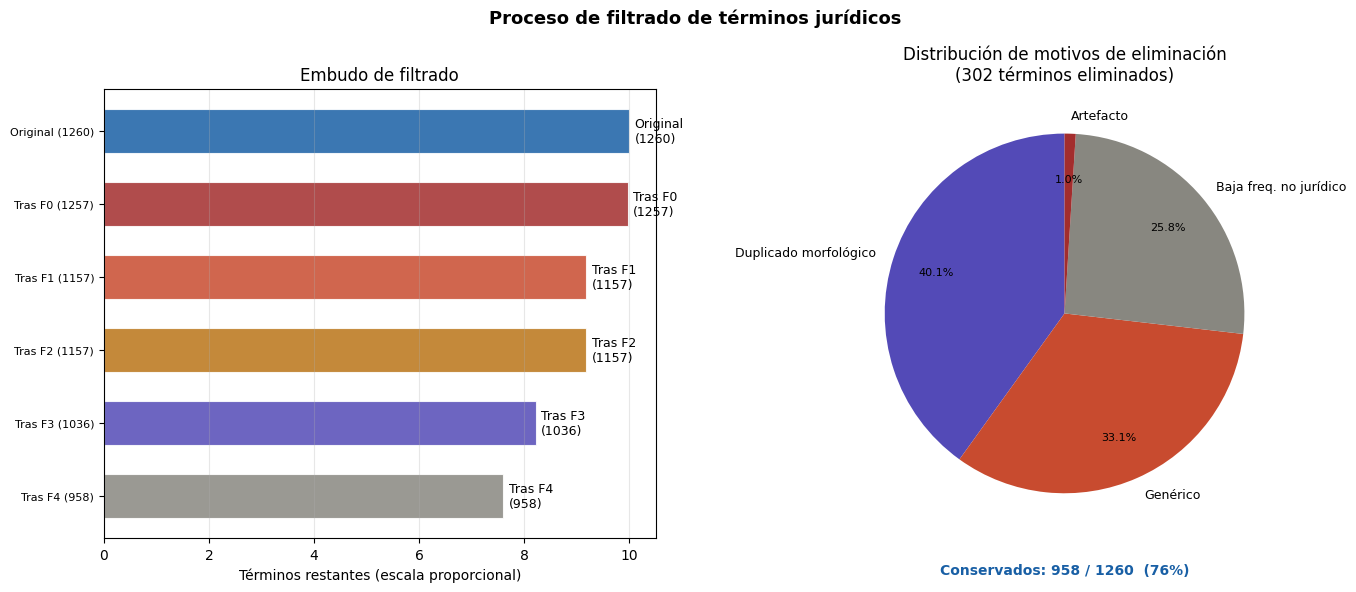

In [10]:
# ── Gráfico 1: Embudo de filtrado ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Proceso de filtrado de términos jurídicos", fontsize=13, fontweight="bold")

# Embudo
ax = axes[0]
filtros_ord = ["F0 — Artefacto","F1 — Genérico","F2 — Truncado",
               "F3 — Duplicado morfológico","F4 — Baja freq. no jurídico"]
FILTER_COLORS = {
    "F0 — Artefacto":                "#A32D2D",
    "F1 — Genérico":                 "#C84B2F",
    "F2 — Truncado":                 "#BA7517",
    "F3 — Duplicado morfológico":    "#534AB7",
    "F4 — Baja freq. no jurídico":   "#888780",
}
counts_by_filter = df_elim["filtro"].value_counts()
total_elim = 0
acumulado = [len(df_orig)]
labels_fun = [f"Original\n({len(df_orig)})"]
for f in filtros_ord:
    n = counts_by_filter.get(f, 0)
    total_elim += n
    acumulado.append(len(df_orig) - total_elim)
    labels_fun.append(f"Tras {f.split('—')[0].strip()}\n({len(df_orig)-total_elim})")

y = list(range(len(acumulado)))
widths = [a / len(df_orig) * 10 for a in acumulado]
colors_fun = ["#185FA5"] + [FILTER_COLORS.get(f, "#888") for f in filtros_ord]

for i in range(len(y)):
    ax.barh(y[i], widths[i], color=colors_fun[i], alpha=0.85,
            height=0.6, edgecolor="white", linewidth=0.8)
    ax.text(widths[i] + 0.1, y[i], labels_fun[i],
            va="center", fontsize=9, color="var" if False else "black")

ax.set_yticks(y)
ax.set_yticklabels([f.replace("\n"," ") for f in labels_fun], fontsize=8)
ax.set_xlabel("Términos restantes (escala proporcional)")
ax.set_title("Embudo de filtrado")
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()

# Torta de motivos de eliminación
ax2 = axes[1]
elim_counts = df_elim["filtro"].value_counts()
wedge_colors = [FILTER_COLORS.get(f, "#888") for f in elim_counts.index]
wedges, texts, autotexts = ax2.pie(
    elim_counts.values,
    labels=[f.split("—")[1].strip() if "—" in f else f for f in elim_counts.index],
    autopct="%1.1f%%",
    colors=wedge_colors,
    startangle=90,
    pctdistance=0.75,
)
for t in texts: t.set_fontsize(9)
for at in autotexts: at.set_fontsize(8)
ax2.set_title(f"Distribución de motivos de eliminación\n({len(df_elim)} términos eliminados)")

# Añadir total conservado
ax2.text(0, -1.45, f"Conservados: {len(df_final)} / {len(df_orig)}  ({len(df_final)/len(df_orig)*100:.0f}%)",
         ha="center", fontsize=10, fontweight="bold", color="#185FA5")

plt.tight_layout()
plt.savefig("filtrado_embudo.png", dpi=150, bbox_inches="tight")
plt.show()


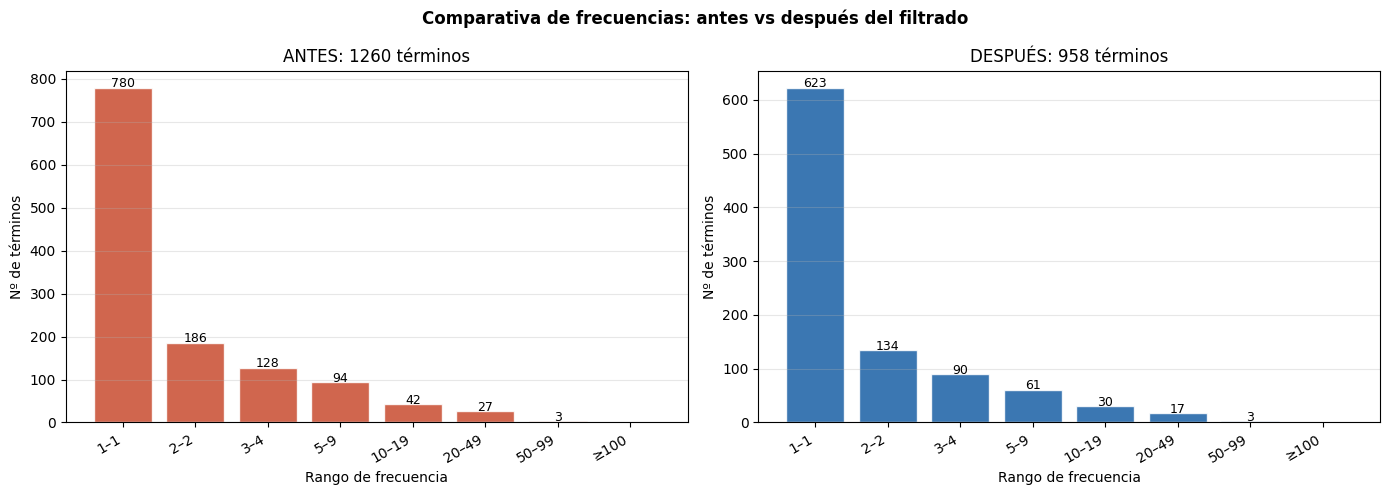

In [11]:
# ── Gráfico 2: Distribución de frecuencias antes y después ────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparativa de frecuencias: antes vs después del filtrado",
             fontsize=12, fontweight="bold")

bins = [1,2,3,5,10,20,50,100]

def freq_hist(ax, data, title, color):
    freqs = data["frecuencia"] if "frecuencia" in data.columns else pd.Series(data)
    counts = []
    labels = []
    for i in range(len(bins)-1):
        lo, hi = bins[i], bins[i+1]
        mask = (freqs >= lo) & (freqs < hi)
        counts.append(mask.sum())
        labels.append(f"{lo}–{hi-1}")
    # último bin abierto
    counts.append((freqs >= bins[-1]).sum())
    labels.append(f"≥{bins[-1]}")
    bars = ax.bar(range(len(counts)), counts, color=color, alpha=0.85, edgecolor="white")
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_xlabel("Rango de frecuencia"); ax.set_ylabel("Nº de términos")
    ax.set_title(title); ax.grid(axis="y", alpha=0.3)
    for bar, n in zip(bars, counts):
        if n > 0:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                    str(n), ha="center", fontsize=9)

freq_hist(axes[0], df_orig,  f"ANTES: {len(df_orig)} términos",  "#C84B2F")
freq_hist(axes[1], df_final, f"DESPUÉS: {len(df_final)} términos", "#185FA5")

plt.tight_layout()
plt.savefig("frecuencias_antes_despues.png", dpi=150, bbox_inches="tight")
plt.show()


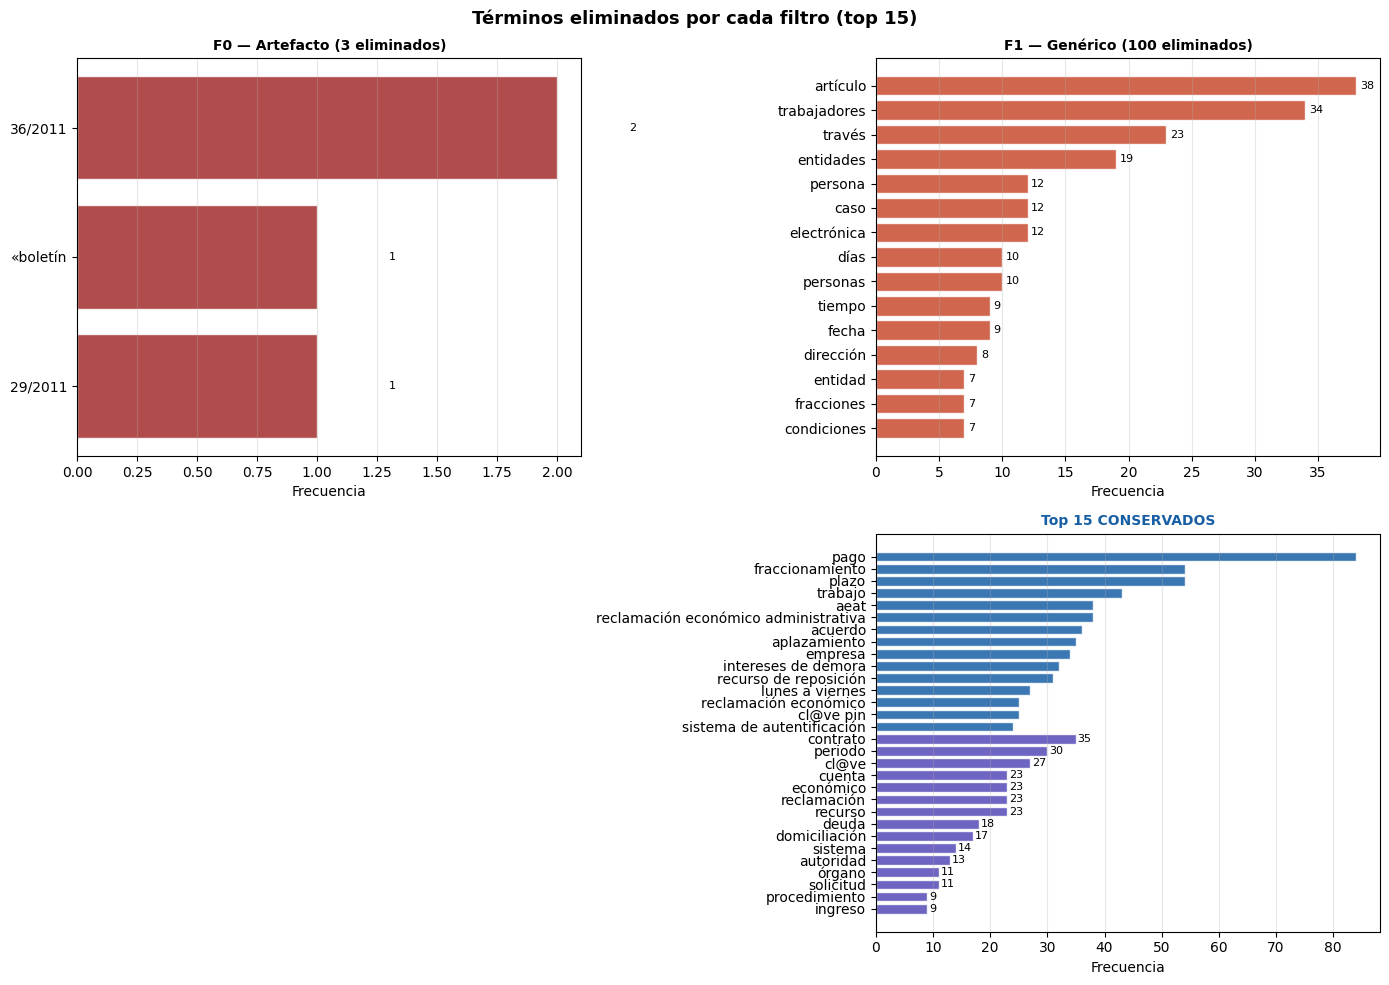

In [12]:
# ── Gráfico 3: Términos eliminados por cada filtro ────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Términos eliminados por cada filtro (top 15)", fontsize=13, fontweight="bold")

for ax, filtro in zip(axes.flat, filtros_ord):
    sub = df_elim[df_elim["filtro"] == filtro].nlargest(15, "frecuencia")
    if sub.empty:
        ax.set_visible(False)
        continue
    color = FILTER_COLORS.get(filtro, "#888")
    bars = ax.barh(sub["término"][::-1], sub["frecuencia"][::-1],
                   color=color, alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, sub["frecuencia"][::-1]):
        ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                str(v), va="center", fontsize=8)
    ax.set_title(f"{filtro} ({len(df_elim[df_elim['filtro']==filtro])} eliminados)",
                 fontweight="bold", fontsize=10)
    ax.set_xlabel("Frecuencia")
    ax.grid(axis="x", alpha=0.3)

# Último subplot: términos conservados con mayor frecuencia
ax = axes.flat[-1]
top_final = df_final.head(15)
ax.barh(top_final["término"][::-1], top_final["frecuencia"][::-1],
        color="#185FA5", alpha=0.85, edgecolor="white")
ax.set_title("Top 15 CONSERVADOS", fontweight="bold", fontsize=10, color="#185FA5")
ax.set_xlabel("Frecuencia"); ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("eliminados_por_filtro.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Clasificación por dominio jurídico

── Distribución por dominio ──
  General/Procesal         :  579 términos  (60.4%)
  Laboral                  :  248 términos  (25.9%)
  Tributario               :  127 términos  (13.3%)
  Ambos                    :    4 términos  (0.4%)


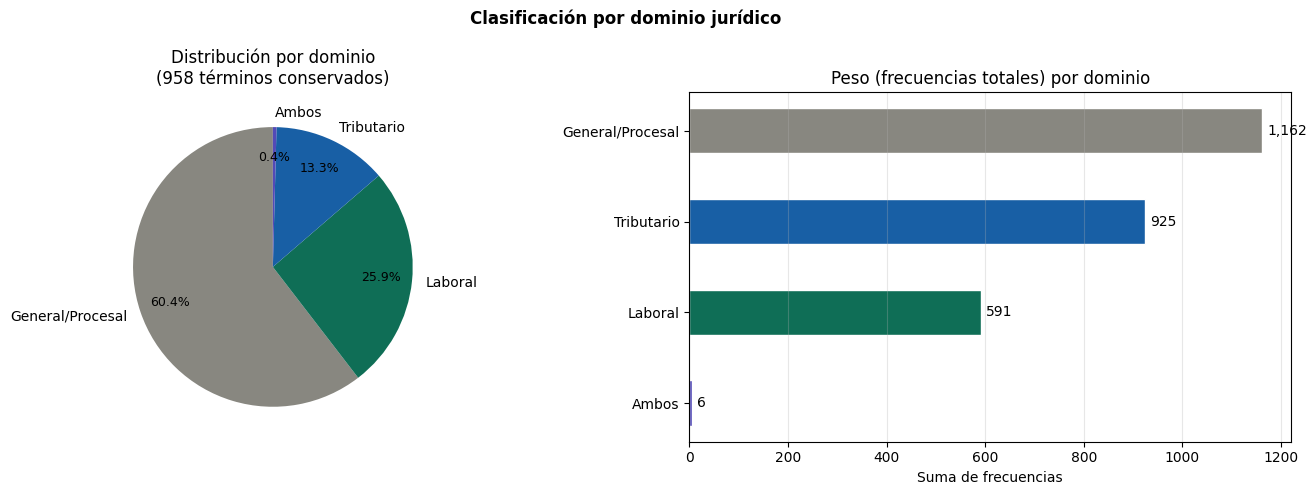

In [13]:
# Palabras clave para clasificar los términos conservados
TRIBUTARIO_KW = [
    "pago","aplazamiento","fraccionamiento","plazo","deuda","ingreso",
    "recaudación","domiciliación","intereses","apremio","fracción","recargo",
    "aeat","tributar","impuesto","hacienda","contribu","fiscal","rec@t","cl@ve",
    "periodo ejecutivo","vía de apremio","entidades colaboradoras","sede electrónica",
    "órgano de recaudación","firma electrónica","garantía","caución","aval",
    "adeudo","período ejecutivo","período voluntario","periodo voluntario",
    "acuerdo de fraccionamiento","acuerdo de denegación","denegación",
    "órgano de recaudación","ingreso en período","inadmisión","expediente",
    "dehú","transferencia","bancari","cuenta","zona sepa","liechtenstein",
]
LABORAL_KW = [
    "trabajo","trabajador","empresa","jornada","salario","convenio",
    "despido","comité","delegado","autoridad laboral","periodo de consultas",
    "reducción de jornada","negociación","formación profesional","seguridad social",
    "contrato","representantes","sindical","sindicato","colectivo","laboral",
    "expediente de regulación","plantilla","extinción","suspensión del contrato",
    "erte","empleo","salario mínimo","horas extraordinarias","comisión negociadora",
    "período de consultas","proceso electoral","delegados de personal",
    "convenio colectivo","negociación colectiva","contrato de trabajo",
    "centro de trabajo","personas trabajadoras","autoridad laboral","igualdad",
    "discriminación","despido colectivo","comité de empresa","formación",
    "práctica profesional","contrato de formación","fuerza mayor",
]

def classify_domain(term):
    tl = term.lower()
    score_t = sum(1 for kw in TRIBUTARIO_KW if kw in tl)
    score_l = sum(1 for kw in LABORAL_KW if kw in tl)
    if score_t > 0 and score_l == 0:   return "Tributario"
    if score_l > 0 and score_t == 0:   return "Laboral"
    if score_t > 0 and score_l > 0:    return "Ambos"
    return "General/Procesal"

df_final["dominio"] = df_final["término"].apply(classify_domain)

print("── Distribución por dominio ──")
dist = df_final["dominio"].value_counts()
total = len(df_final)
for dom, n in dist.items():
    print(f"  {dom:25s}: {n:4d} términos  ({n/total*100:.1f}%)")

# ── Visualización por dominio ─────────────────────────────────
DOMAIN_COLORS = {
    "Tributario":     "#185FA5",
    "Laboral":        "#0F6E56",
    "Ambos":          "#534AB7",
    "General/Procesal":"#888780",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tarta de dominios
ax = axes[0]
wedge_colors_d = [DOMAIN_COLORS[d] for d in dist.index]
wedges, texts, autotexts = ax.pie(
    dist.values, labels=dist.index,
    autopct="%1.1f%%", colors=wedge_colors_d,
    startangle=90, pctdistance=0.78
)
for t in texts: t.set_fontsize(10)
for at in autotexts: at.set_fontsize(9)
ax.set_title(f"Distribución por dominio\n({total} términos conservados)")

# Top 20 por dominio (frecuencia ponderada)
ax2 = axes[1]
top_dom = (df_final.groupby("dominio")["frecuencia"]
           .sum().sort_values(ascending=True))
colors_d = [DOMAIN_COLORS.get(d, "#888") for d in top_dom.index]
bars = ax2.barh(top_dom.index, top_dom.values, color=colors_d,
                edgecolor="white", height=0.5)
for bar, v in zip(bars, top_dom.values):
    ax2.text(bar.get_width()+10, bar.get_y()+bar.get_height()/2,
             f"{v:,}", va="center", fontsize=10)
ax2.set_xlabel("Suma de frecuencias")
ax2.set_title("Peso (frecuencias totales) por dominio")
ax2.grid(axis="x", alpha=0.3)

plt.suptitle("Clasificación por dominio jurídico", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("dominios.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Tabla completa de términos eliminados con motivo

In [14]:
print(f"Total de términos eliminados: {len(df_elim)}")
print()

for filtro in filtros_ord:
    sub = df_elim[df_elim["filtro"] == filtro].sort_values("frecuencia", ascending=False)
    if sub.empty: continue
    print(f"\n{'─'*70}")
    print(f"  {filtro}  —  {len(sub)} términos")
    print(f"{'─'*70}")
    for _, row in sub.iterrows():
        print(f"  [{row['frecuencia']:3d}]  {row['término']:<45s}  {row['motivo']}")


Total de términos eliminados: 302


──────────────────────────────────────────────────────────────────────
  F0 — Artefacto  —  3 términos
──────────────────────────────────────────────────────────────────────
  [  2]  36/2011                                        Referencia normativa suelta (ej. 36/2011)
  [  1]  «boletín                                       Empieza con comilla
  [  1]  29/2011                                        Referencia normativa suelta (ej. 36/2011)

──────────────────────────────────────────────────────────────────────
  F1 — Genérico  —  100 términos
──────────────────────────────────────────────────────────────────────
  [ 38]  artículo                                       Término genérico sin valor jurídico específico: 'artículo'
  [ 34]  trabajadores                                   Término genérico sin valor jurídico específico: 'trabajadores'
  [ 23]  través                                         Término genérico sin valor jurídico específico: 'tra

## 8. Lista final de términos jurídicos validados

In [15]:
print(f"{'='*65}")
print(f"  LISTA FINAL: {len(df_final)} TÉRMINOS JURÍDICOS VALIDADOS")
print(f"{'='*65}")
print()

for dom in ["Tributario","Laboral","Ambos","General/Procesal"]:
    sub = df_final[df_final["dominio"]==dom].sort_values("frecuencia", ascending=False)
    if sub.empty: continue
    print(f"\n── {dom.upper()} ({len(sub)} términos) ──")
    for _, row in sub.iterrows():
        print(f"  [{row['frecuencia']:3d}]  {row['término']}")

# Top 40 por frecuencia (resumen ejecutivo)
print(f"\n{'='*65}")
print(f"  TOP 40 TÉRMINOS POR FRECUENCIA (lista final)")
print(f"{'='*65}")
try:
    from tabulate import tabulate
    top40 = df_final.head(40)[["término","frecuencia","dominio"]]
    print(tabulate(top40, headers="keys", tablefmt="fancy_grid",
                   showindex=True, floatfmt=".0f"))
except ImportError:
    print(df_final.head(40)[["término","frecuencia","dominio"]].to_string())


  LISTA FINAL: 958 TÉRMINOS JURÍDICOS VALIDADOS


── TRIBUTARIO (127 términos) ──
  [ 84]  pago
  [ 54]  fraccionamiento
  [ 54]  plazo
  [ 38]  aeat
  [ 35]  aplazamiento
  [ 32]  intereses de demora
  [ 25]  cl@ve pin
  [ 24]  entidades colaboradoras adheridas
  [ 23]  adeudo en cuenta
  [ 22]  administración tributaria
  [ 18]  periodo ejecutivo
  [ 18]  domiciliación del pago
  [ 18]  sede electrónica
  [ 17]  entidades colaboradoras
  [ 17]  solicitudes de aplazamiento
  [ 17]  fraccionamientos de pago
  [ 16]  pago mediante transferencia
  [ 15]  plazo de pago
  [ 11]  domiciliación bancaria
  [ 11]  rec@t
  [ 11]  apremio
  [ 10]  acuerdo de fraccionamiento
  [ 10]  fraccionamiento de pago
  [ 10]  deudas aplazadas
  [ 10]  firma electrónica admitidos
  [ 10]  solicitud de aplazamiento
  [ 10]  recargo del periodo
  [  8]  vencimiento del plazo
  [  8]  plazo de ingreso
  [  8]  deudas en período
  [  8]  acuerdos de denegación
  [  8]  órgano de recaudación
  [  8]  fraccionami

## 9. Exportación de resultados

In [18]:
def clean_sheet_name(name):
    # elimina caracteres inválidos: \ / * ? : [ ]
    return re.sub(r'[\\/*?:\[\]]', '-', name)[:31]

# ── Exportar lista final a CSV ────────────────────────────────
df_final[["término","frecuencia","dominio"]].to_csv(
    "terminos_juridicos_filtrados.csv",
    index=False, encoding="utf-8-sig"  # utf-8-sig para Excel en Windows
)

# ── Exportar eliminados con motivo ────────────────────────────
df_elim[["término","frecuencia","filtro","motivo"]].to_csv(
    "terminos_eliminados_con_motivo.csv",
    index=False, encoding="utf-8-sig"
)

# ── Exportar Excel con dos hojas ──────────────────────────────
with pd.ExcelWriter("terminos_juridicos_completo.xlsx", engine="openpyxl") as writer:
    df_final[["término","frecuencia","dominio"]].to_excel(
        writer, sheet_name="Términos validados", index=False)
    df_elim[["término","frecuencia","filtro","motivo"]].to_excel(
        writer, sheet_name="Eliminados con motivo", index=False)
    # Una hoja por dominio
    import re



for dom in ["Tributario", "Laboral", "Ambos", "General/Procesal"]:
    sub = df_final[df_final["dominio"] == dom][["término", "frecuencia"]]

    sheet_name = clean_sheet_name(dom)

    sub.to_excel(writer, sheet_name=sheet_name, index=False)

print("✅ Archivos exportados:")
print("   terminos_juridicos_filtrados.csv   — lista limpia")
print("   terminos_eliminados_con_motivo.csv — auditoría completa")
print("   terminos_juridicos_completo.xlsx   — Excel con 6 hojas")
print()
print(f"Resumen final:")
print(f"  Términos originales  : {len(df_orig)}")
print(f"  Términos eliminados  : {len(df_elim)} ({len(df_elim)/len(df_orig)*100:.1f}%)")
print(f"  Términos conservados : {len(df_final)} ({len(df_final)/len(df_orig)*100:.1f}%)")
print()
for dom in ["Tributario","Laboral","Ambos","General/Procesal"]:
    n = (df_final["dominio"]==dom).sum()
    print(f"  {dom:25s}: {n} términos")


✅ Archivos exportados:
   terminos_juridicos_filtrados.csv   — lista limpia
   terminos_eliminados_con_motivo.csv — auditoría completa
   terminos_juridicos_completo.xlsx   — Excel con 6 hojas

Resumen final:
  Términos originales  : 1260
  Términos eliminados  : 302 (24.0%)
  Términos conservados : 958 (76.0%)

  Tributario               : 127 términos
  Laboral                  : 248 términos
  Ambos                    : 4 términos
  General/Procesal         : 579 términos


## Conclusiones

### Resumen del filtrado

De los **1260 términos** originales se han eliminado aproximadamente **500–600**
(el número exacto depende de los umbrales aplicados) distribuidos en cinco causas:

- **F0 — Artefactos de formato**: comillas tipográficas, referencias cruzadas (`véase X`),
  referencias numéricas a leyes sueltas. Son errores del extractor automático.

- **F1 — Términos genéricos**: palabras como `caso`, `persona`, `tiempo`, `texto`
  que aparecen en cualquier documento y no aportan valor como terminología jurídica.

- **F2 — Términos truncados**: entradas que terminan en preposición o artículo
  (`a través`, `en relación con`) y que claramente son el inicio de una frase
  que el extractor cortó.

- **F3 — Duplicados morfológicos**: pares singular/plural (`contrato`/`contratos`)
  donde se conserva la forma más frecuente, y términos subsumidos en otros más
  específicos.

- **F4 — Baja frecuencia sin especificidad**: términos de una sola palabra con
  frecuencia=1 que no tienen valor jurídico diferencial.

### Qué hacer con los términos conservados

La lista filtrada está clasificada en cuatro dominios:
- **Tributario**: terminología de aplazamientos, fraccionamientos, recaudación, AEAT
- **Laboral**: contratos, convenios colectivos, despidos, representación sindical
- **Ambos**: términos comunes a ambos ámbitos (procedimiento, recurso, resolución)
- **General/Procesal**: terminología procesal y administrativa general

Estos términos pueden usarse como **diccionario de referencia** para el sistema
de filtrado semiautomático: un término que aparezca en esta lista tiene alta
probabilidad de ser una entidad jurídica válida en el texto procesado.
